In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict
)
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_squared_error, accuracy_score,
    precision_score, recall_score, f1_score
)

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

In [2]:
def compute_metrics(y_true, y_pred, label=""):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    return {
        "Set": label,
        "MSE": round(mse, 4),
        "RMSE": round(rmse, 4),
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1": round(f1, 4)
    }

In [3]:
def remove_outliers_iqr(df, features):
    for feature in features:
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1
        df = df[(df[feature] >= Q1 - 1.5 * IQR) & (df[feature] <= Q3 + 1.5 * IQR)]
    return df

In [17]:
from scipy import stats
from sklearn.datasets import fetch_california_housing
california_housing = fetch_california_housing(as_frame=True)
df = california_housing.frame

df_o = remove_outliers_iqr(df, ['MedInc', 'HouseAge','AveRooms','AveBedrms','Population','AveOccup','MedHouseVal'])
df_o = df_o.rename(columns={'MedHouseVal': 'target'})
df_final = df_o.iloc[:,[1,2,3,4,5,6,7,0,8]]
df_final['target'] = df_final.apply(lambda row: 0 if (row['target']<0.7)else 1, axis=1)

X_train, X_test = train_test_split(df_final, test_size=0.2, random_state=2)

scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=df_final.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=df_final.columns)

X_train = X_train_scaled.iloc[:, :-1]
X_test = X_test_scaled.iloc[:, :-1]
y_train = X_train_scaled.iloc[:, -1]
y_test = X_test_scaled.iloc[:, -1]

In [5]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

models = {
    "Naive Bayes": {
        "pipeline": Pipeline([
            ("scaler", MinMaxScaler()),
            ("clf", GaussianNB())
        ]),
        "params": {
            "clf__var_smoothing": np.logspace(-9, -6, 7)
        }
    },

    "Logistic Regression": {
        "pipeline": Pipeline([
            ("scaler", MinMaxScaler()),
            ("clf", LogisticRegression(max_iter=100, random_state=2))
        ]),
        "params": {
            "clf__C": [0.001, 0.1, 1, 10]
        }
    },

    "Random Forest": {
        "pipeline": Pipeline([
            ("scaler", MinMaxScaler()),
            ("clf", RandomForestClassifier(random_state=2))
        ]),
        "params": {
            "clf__n_estimators": [50, 100, 200, 500],
            "clf__max_depth": [None, 2, 10]
        }
    },

    "Neural Network": {
        "pipeline": Pipeline([
            ("scaler", MinMaxScaler()),
            ("clf", MLPClassifier(max_iter=500, random_state=2))
        ]),
        "params": {
            "clf__hidden_layer_sizes": [(10,), (20,), (50,), (10,10), (50,50)],
            "clf__activation": ["relu", "tanh"],
            "clf__solver": ['adam', 'sgd']
        }
    }
}

In [6]:
all_results = []

for name, config in models.items():
    print(f"\n{'='*60}")
    print(f"  Model: {name}")
    print(f"{'='*60}")

    gs = GridSearchCV(
        estimator=config["pipeline"],
        param_grid=config["params"],
        cv=cv,
        scoring='accuracy',
        n_jobs=-1,
        verbose=0
    )
    gs.fit(X_train, y_train)

    best_model = gs.best_estimator_
    print(f"  The best params : {gs.best_params_}")
    print(f"  CV F1 (val. set)   : {gs.best_score_:.4f}")

    y_train_pred = cross_val_predict(best_model, X_train, y_train, cv=cv)
    train_metrics = compute_metrics(y_train, y_train_pred, label="Train (CV)")

    y_test_pred = best_model.predict(X_test)
    test_metrics = compute_metrics(y_test, y_test_pred, label="Test")

    for m in [train_metrics, test_metrics]:
        print(f"\n  [{m['Set']}]")
        for k, v in m.items():
            if k != "Set":
                print(f"    {k:<12}: {v}")

    all_results.append({"Model": name, **train_metrics})
    all_results.append({"Model": name, **test_metrics})


  Model: Naive Bayes
  The best params : {'clf__var_smoothing': 1e-09}
  CV F1 (val. set)   : 0.9361

  [Train (CV)]
    MSE         : 0.0639
    RMSE        : 0.2528
    Accuracy    : 0.9361
    Precision   : 0.9581
    Recall      : 0.9743
    F1          : 0.9661

  [Test]
    MSE         : 0.0659
    RMSE        : 0.2567
    Accuracy    : 0.9341
    Precision   : 0.9585
    Recall      : 0.9717
    F1          : 0.9651

  Model: Logistic Regression
  The best params : {'clf__C': 10}
  CV F1 (val. set)   : 0.9469

  [Train (CV)]
    MSE         : 0.0531
    RMSE        : 0.2304
    Accuracy    : 0.9469
    Precision   : 0.9562
    Recall      : 0.9886
    F1          : 0.9721

  [Test]
    MSE         : 0.0539
    RMSE        : 0.2322
    Accuracy    : 0.9461
    Precision   : 0.957
    Recall      : 0.9869
    F1          : 0.9717

  Model: Random Forest
  The best params : {'clf__max_depth': None, 'clf__n_estimators': 500}
  CV F1 (val. set)   : 0.9666

  [Train (CV)]
    MSE    

In [7]:
print(f"\n\n{'='*60}")
print("Metrics")
print(f"{'='*60}")
df_results = pd.DataFrame(all_results)
df_results = df_results.set_index(["Model", "Set"])
print(df_results.to_string())



Metrics
                                   MSE    RMSE  Accuracy  Precision  Recall      F1
Model               Set                                                            
Naive Bayes         Train (CV)  0.0639  0.2528    0.9361     0.9581  0.9743  0.9661
                    Test        0.0659  0.2567    0.9341     0.9585  0.9717  0.9651
Logistic Regression Train (CV)  0.0531  0.2304    0.9469     0.9562  0.9886  0.9721
                    Test        0.0539  0.2322    0.9461     0.9570  0.9869  0.9717
Random Forest       Train (CV)  0.0334  0.1828    0.9666     0.9724  0.9924  0.9823
                    Test        0.0357  0.1890    0.9643     0.9732  0.9892  0.9811
Neural Network      Train (CV)  0.0352  0.1876    0.9648     0.9751  0.9877  0.9813
                    Test        0.0379  0.1946    0.9621     0.9790  0.9806  0.9798


In [8]:
def yes_function(x, y, a, kappa, lam, gamma=1):
    return 1 - np.maximum(0.0, ((1-x)**kappa + (1-y)**kappa - (1-a)**kappa))**(1/kappa)

def no_function(x, y, a, kappa, lam, gamma=1):
    return np.maximum(0.0, (x**lam + y**lam - a**lam))**(1/lam)

def maybe_function(x, y, a, kappa, lam, gamma=1):
    if x is None or y is None:
        return 0
    if gamma == 0:
        return 0
    a = np.clip(a, 1e-6, 1 - 1e-6)
    x = np.clip(x, 0, 1)
    y = np.clip(y, 0, 1)
    value = gamma*(1/a)*x*y + (1-gamma)*(1 - (1/(1-a))*(1-x)*(1-y))
    return statistics.median([0, 1, value])

def classification(x, y, a, kappa, lam, gamma):
    if x < a and y < a:
        return no_function(x, y, a, 1, lam, 1)
    elif x > a and y > a:
        return yes_function(x, y, a, kappa, 1, 1)
    else:
        return maybe_function(x, y, a, 1, 1, gamma)

def classification_vec(values, diffs, a, kappa, lam, gamma):
    if values.size == 0 or diffs.size == 0:
        return np.zeros_like(values)

    results = np.zeros_like(values, dtype=float)
    mask_no    = (values < a) & (diffs < a)
    mask_yes   = (values > a) & (diffs > a)
    mask_maybe = ~(mask_no | mask_yes)

    if np.any(mask_no):
        results[mask_no] = no_function(values[mask_no], diffs[mask_no], a, 1, lam, 1)
    if np.any(mask_yes):
        results[mask_yes] = yes_function(values[mask_yes], diffs[mask_yes], a, kappa, 1, 1)
    if np.any(mask_maybe):
        for idx in np.where(mask_maybe)[0]:
            results[idx] = maybe_function(values[idx], diffs[idx], a, 1, 1, gamma)

    return np.round(results, 4)

In [9]:
def show_results(data, mean_error, gamma_result, lam_result, kappa_result, a_result):
    target_values = data[['target']].values
    value = data[['calc_value']].values
    MSE = mean_squared_error(target_values, value)
    RMSE = math.sqrt(MSE)
    print('Results:')
    if all(col in data.columns for col in ['value','error']):
      print(data.drop(columns=['value','error']))
    else:
      print(data)
    print('\u03B3 = ', round(gamma_result, 4))
    print('\u03BB = ', round(lam_result, 4))
    print('\u03BA = ', round(kappa_result, 4))
    print('a = ', round(a_result, 4))
    print('Mean squared error = ', round(MSE, 4))
    print('Root Mean Square Error = ', round(RMSE, 4))

In [10]:
def calculate_tests(target_values, value):
  print('Accuracy score = ', accuracy_score(target_values, value))
  print('F1 = ', f1_score(target_values, value))
  print('Precision = ', precision_score(target_values, value))
  print('Recall = ', recall_score(target_values, value))
  confusion_matrix = metrics.confusion_matrix(target_values, value)
  cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])
  cm_display.plot()
  plt.show()

Accuracy score =  0.24921062764728533
F1 =  0.3395433913691484
Precision =  0.20620422940837654
Recall =  0.9608895705521472


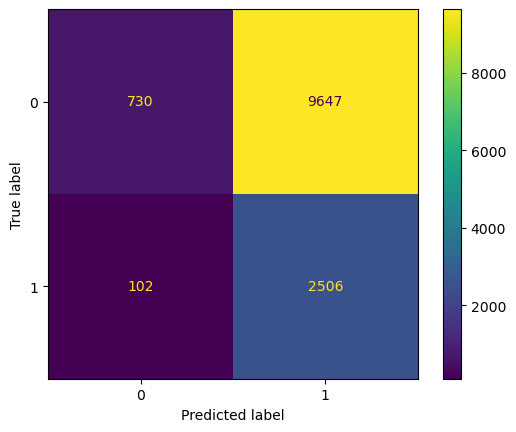

In [11]:
import statistics
from sklearn import metrics
import matplotlib.pyplot as plt
columns=len(X_train_scaled.columns)
X_train_scaled['calc_value']=X_train_scaled.apply(lambda row: row[0], axis =1)
j=0
while j < columns-2:
  X_train_scaled['calc_value']=X_train_scaled.apply(lambda row: classification(row['calc_value'], row[j+1], 0.5, 1, 1, 0.5), axis = 1)
  j += 1
X_train_scaled['calc_value_class'] = X_train_scaled.apply(lambda row: 0 if (row['calc_value']<= 0.5)else 1, axis=1)
X_train_scaled['target_class'] = X_train_scaled.apply(lambda row: 0 if (row['target']<= 0.5)else 1, axis=1)
calculate_tests(X_train_scaled[["calc_value_class"]].values, X_train_scaled[['target_class']].values)

In [12]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, mean_squared_error
import math
columns=len(X_test_scaled.columns)
X_test_scaled['calc_value']=X_test_scaled.apply(lambda row: row[0], axis =1)
j=0
while j < columns-2:
  X_test_scaled['calc_value']=X_test_scaled.apply(lambda row: classification(row['calc_value'], row[j+1],  0.5, 1, 1, 0.5), axis = 1)
  j += 1
show_results(X_test_scaled, 0, 0, 0, 0, 0)

Results:
      HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0     0.431373  0.856210   0.529258    0.442556  0.609795  0.160468   
1     0.686275  0.525870   0.203205    0.523765  0.761286  0.146652   
2     0.392157  0.588852   0.227864    0.319799  0.492305  0.583422   
3     0.686275  0.647610   0.522866    0.222222  0.313524  0.628055   
4     1.000000  0.242021   0.207369    0.261882  0.498898  0.553666   
...        ...       ...        ...         ...       ...       ...   
3242  1.000000  0.624418   0.727244    0.340573  0.394231  0.510096   
3243  0.098039  0.484323   0.328678    0.132515  0.329538  0.096706   
3244  0.274510  0.436709   0.437477    0.589865  0.223366  0.129649   
3245  0.431373  0.560195   0.475277    0.473088  0.512056  0.182784   
3246  0.568627  0.383582   0.426398    0.241108  0.278919  0.117960   

      Longitude    MedInc  target  calc_value  
0      0.735174  0.740705     1.0    1.000000  
1      0.640082  0.557004     1.0    0.544

In [13]:
X_test_scaled['target_class'] = X_test_scaled.apply(lambda row: 0 if (row['target']<0.5)else 1, axis=1)
X_test_scaled['calc_value_class'] = X_test_scaled.apply(lambda row: 0 if (row['calc_value']< 0.5)else 1, axis=1)

In [14]:
target_values = X_test_scaled[['target_class']].values
value = X_test_scaled[['calc_value_class']].values

Accuracy score =  0.25562057283646444
F1 =  0.34799028864310766
Precision =  0.9713855421686747
Recall =  0.2119618797239566


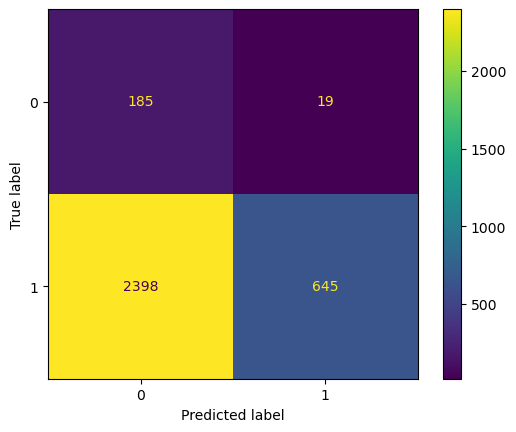

In [15]:
calculate_tests(target_values, value)

In [19]:
import numpy as np
import statistics
import itertools
from tqdm import tqdm

def error_metric(values, labels, a, kappa, lam, gamma):
    columns = len(X_test_scaled.columns)
    X_test_scaled['calc_value'] = X_test_scaled.apply(lambda row: row[0], axis=1)
    j = 0
    while j < columns - 2:
        X_test_scaled['calc_value'] = X_test_scaled.apply(
            lambda row: classification(row['calc_value'], row[j+1], a, kappa, lam, gamma), axis=1
        )
        j += 1
    return np.mean(np.abs(X_test_scaled['calc_value'] - labels))

def randomized_grid_search(values, labels, n_iter=2000, random_state=42):
    np.random.seed(random_state)

    a_range     = np.round(np.arange(0.1, 1, 0.05), 2)
    gamma_range = np.round(np.arange(0.1, 1, 0.05), 2)
    kappa_range = np.round(np.arange(0.1, 3, 0.05), 2)
    lam_range   = np.round(np.arange(0.1, 3, 0.05), 2)

    all_combos = list(itertools.product(a_range, kappa_range, lam_range, gamma_range))
    n_iter = min(n_iter, len(all_combos))
    sampled = [all_combos[i] for i in np.random.choice(len(all_combos), size=n_iter, replace=False)]

    best_params = None
    best_error  = np.inf
    results     = []

    print(f"Ukupno kombinacija: {len(all_combos)}")
    print(f"Nasumično uzorkovano: {n_iter}")

    for a, kappa, lam, gamma in tqdm(sampled):
        if kappa == 0 or lam == 0:
            continue
        try:
            error = error_metric(values, labels, a, kappa, lam, gamma)
        except Exception:
            continue

        results.append({
            "a": a, "kappa": kappa, "lam": lam, "gamma": gamma,
            "error": error
        })

        if error < best_error:
            best_error  = error
            best_params = {"a": a, "kappa": kappa, "lam": lam, "gamma": gamma}

    print("\nBest params:")
    print(f"  a     = {best_params['a']}")
    print(f"  kappa = {best_params['kappa']}")
    print(f"  lam   = {best_params['lam']}")
    print(f"  gamma = {best_params['gamma']}")
    print(f"  greška (MAE) = {best_error:.6f}")

    return best_params, best_error, results

if __name__ == "__main__":
    values = X_train
    labels = y_train
    best_params, best_error, all_results = randomized_grid_search(values, labels, n_iter=2000)

Ukupno kombinacija: 1089936
Nasumično uzorkovano: 2000


100%|██████████| 2000/2000 [36:04<00:00,  1.08s/it]



Best params:
  a     = 0.1
  kappa = 2.0
  lam   = 1.75
  gamma = 0.1
  greška (MAE) = 0.069202


Accuracy score =  0.9359260685406238
F1 =  0.9669026971119421
Precision =  1.0
Recall =  0.9359260685406238


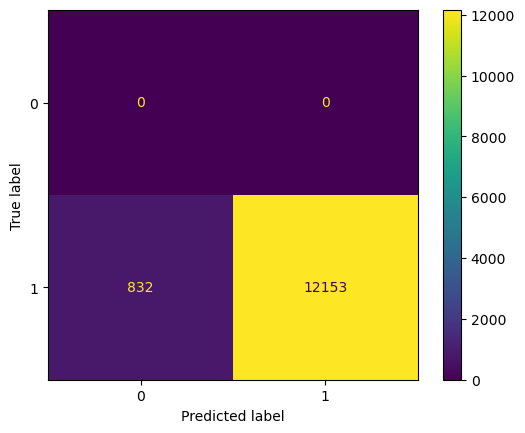

In [21]:
columns=len(X_train_scaled.columns)
X_train_scaled['calc_value']=X_train_scaled.apply(lambda row: row[0], axis =1)
j=0
while j < columns-2:
  X_train_scaled['calc_value']=X_train_scaled.apply(lambda row: classification(row['calc_value'], row[j+1], 0.1, 2.0, 1.75, 0.1), axis = 1)
  j += 1
X_train_scaled['calc_value_class'] = X_train_scaled.apply(lambda row: 0 if (row['calc_value']<= 0.1)else 1, axis=1)
X_train_scaled['target_class'] = X_train_scaled.apply(lambda row: 0 if (row['target']<= 0.1)else 1, axis=1)
calculate_tests(X_train_scaled[["calc_value_class"]].values, X_train_scaled[['target_class']].values)

Results:
      HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0     0.431373  0.856210   0.529258    0.442556  0.609795  0.160468   
1     0.686275  0.525870   0.203205    0.523765  0.761286  0.146652   
2     0.392157  0.588852   0.227864    0.319799  0.492305  0.583422   
3     0.686275  0.647610   0.522866    0.222222  0.313524  0.628055   
4     1.000000  0.242021   0.207369    0.261882  0.498898  0.553666   
...        ...       ...        ...         ...       ...       ...   
3242  1.000000  0.624418   0.727244    0.340573  0.394231  0.510096   
3243  0.098039  0.484323   0.328678    0.132515  0.329538  0.096706   
3244  0.274510  0.436709   0.437477    0.589865  0.223366  0.129649   
3245  0.431373  0.560195   0.475277    0.473088  0.512056  0.182784   
3246  0.568627  0.383582   0.426398    0.241108  0.278919  0.117960   

      Longitude    MedInc  target  calc_value  target_class  calc_value_class  
0      0.735174  0.740705     1.0         1.0             

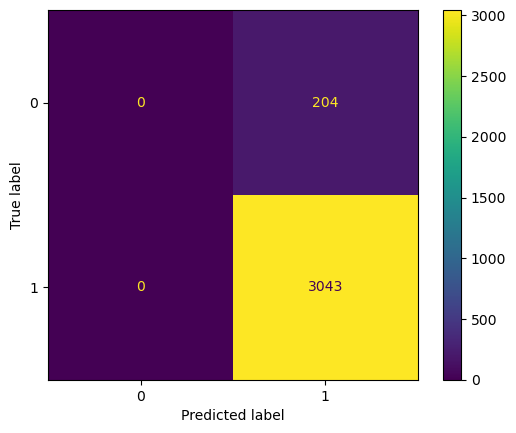

In [29]:
columns=len(X_test_scaled.columns)
X_test_scaled['calc_value']=X_test_scaled.apply(lambda row: row[0], axis =1)
j=0
while j < columns-2:
  X_test_scaled['calc_value']=X_test_scaled.apply(lambda row: classification(row['calc_value'], row[j+1], 0.1, 2.0, 1.75, 0.1), axis = 1)
  j += 1
show_results(X_test_scaled, 0, 0, 0, 0, 0)
X_test_scaled['target_class'] = X_test_scaled.apply(lambda row: 0 if (row['target']<= 0.1)else 1, axis=1)
X_test_scaled['calc_value_class'] = X_test_scaled.apply(lambda row: 0 if (row['calc_value']<= 0.1)else 1, axis=1)
target_values = X_test_scaled[['target_class']].values
value = X_test_scaled[['calc_value_class']].values
calculate_tests(target_values, value)